# 1. Import

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import joblib  # for saving the model

In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


# 2. Read In Data

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(r"C:\Users\prpa2\OneDrive\Desktop\final datasets\Metro_Interstate_Traffic_Volume.csv")

In [5]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


# 3. Remove Missing Values

In [6]:
df[['rain_1h','snow_1h','clouds_all']] = df[['rain_1h','snow_1h','clouds_all']].fillna(0)

# 4. Remove Duplicates

In [7]:
df = df.drop_duplicates()

# 5. Convert date_time to proper format

In [8]:
df['date_time'] = pd.to_datetime(df['date_time'])

# 6. Extract useful features

In [9]:
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month

# 7. Drop irrelevant columns

In [10]:
df = df.drop(['holiday', 'weather_description'], axis=1)

# 8. Visualization

# 8.1 Hourly Traffic Pattern

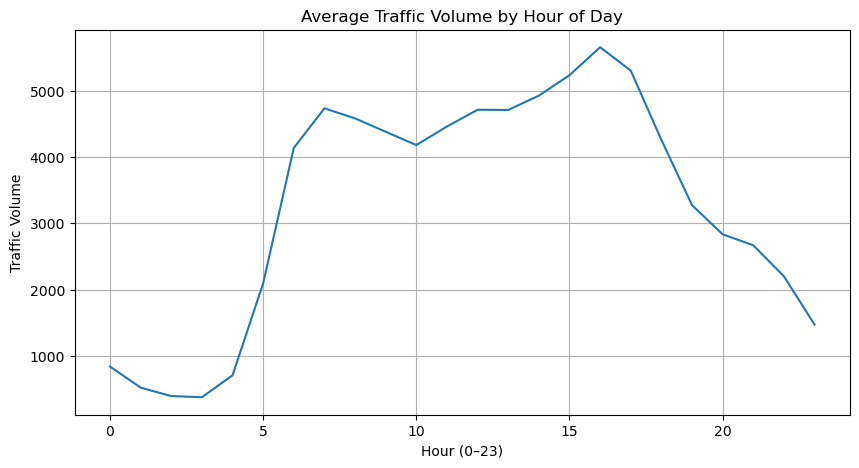

In [11]:
import matplotlib.pyplot as plt

hourly = df.groupby('hour')['traffic_volume'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly)
plt.title("Average Traffic Volume by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Traffic Volume")
plt.grid(True)
plt.show()

# 8.2 Weekly Traffic Pattern (Mon–Sun)

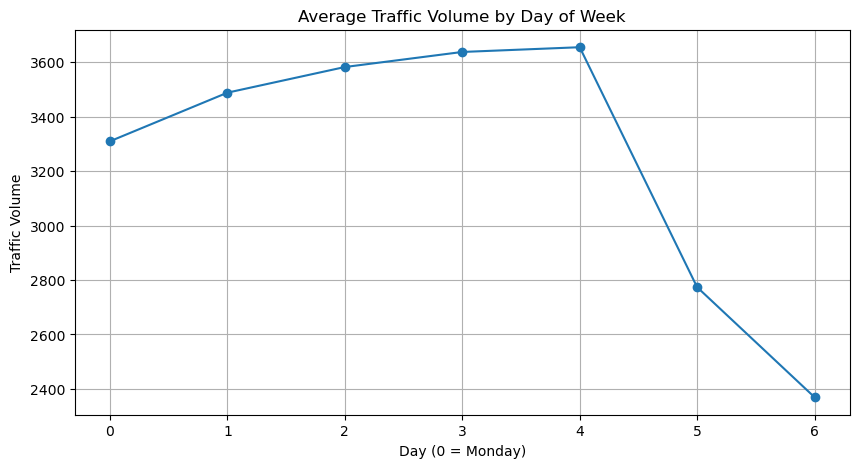

In [12]:
weekly = df.groupby('day_of_week')['traffic_volume'].mean()

plt.figure(figsize=(10,5))
plt.plot(weekly, marker='o')
plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day (0 = Monday)")
plt.ylabel("Traffic Volume")
plt.grid(True)
plt.show()

# 8.3 Monthly Traffic Pattern

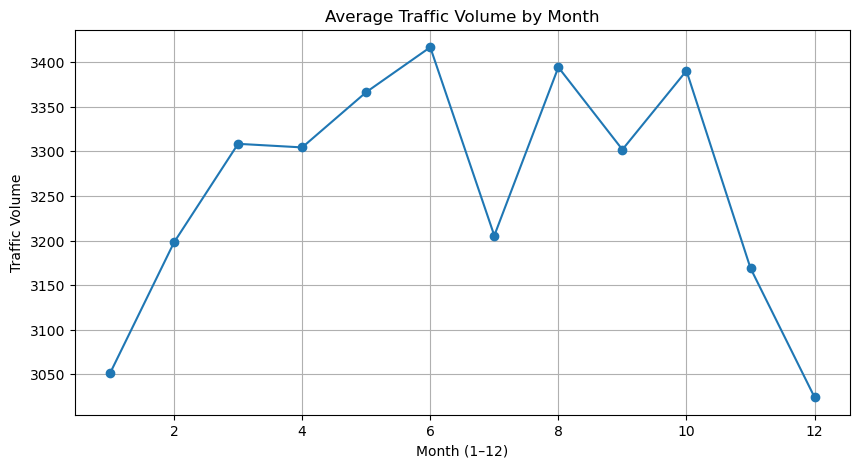

In [13]:
monthly = df.groupby('month')['traffic_volume'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly, marker='o')
plt.title("Average Traffic Volume by Month")
plt.xlabel("Month (1–12)")
plt.ylabel("Traffic Volume")
plt.grid(True)
plt.show()

# 8.4 Hour vs Day Heatmap

In [14]:
heat_data = df.pivot_table(
    values='traffic_volume',
    index='day_of_week',
    columns='hour',
    aggfunc='mean'
)

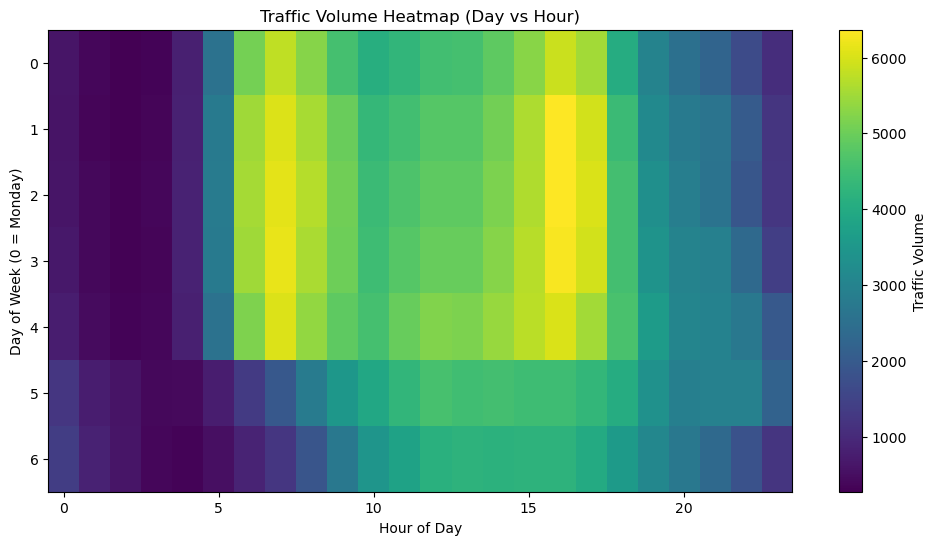

In [15]:
plt.figure(figsize=(12,6))
plt.imshow(heat_data, aspect='auto')
plt.colorbar(label='Traffic Volume')
plt.title("Traffic Volume Heatmap (Day vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0 = Monday)")
plt.show()

In [16]:
df['weather_main'].unique()

array(['Clouds', 'Clear', 'Rain', 'Drizzle', 'Mist', 'Haze', 'Fog',
       'Thunderstorm', 'Snow', 'Squall', 'Smoke'], dtype=object)

In [17]:
['Clear', 'Clouds', 'Rain', 'Snow', 'Mist', ...]

['Clear', 'Clouds', 'Rain', 'Snow', 'Mist', Ellipsis]

In [18]:
weather_groups = df.groupby('weather_main')['traffic_volume'].apply(list)

C:\Users\prpa2\AppData\Local\Temp\ipykernel_2032\4031470699.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(weather_groups, labels=weather_groups.index)


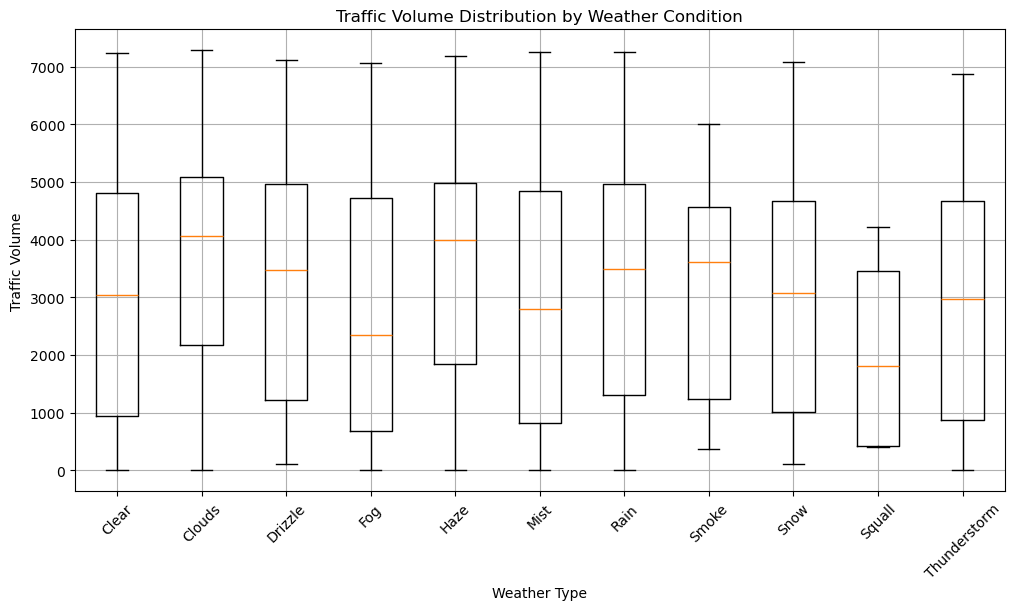

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.boxplot(weather_groups, labels=weather_groups.index)

plt.title("Traffic Volume Distribution by Weather Condition")
plt.xlabel("Weather Type")
plt.ylabel("Traffic Volume")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [20]:
df['date_time'] = pd.to_datetime(df['date_time'])

In [21]:
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek   # 0 = Monday
df['month'] = df['date_time'].dt.month

In [22]:
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [23]:
feature_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all',
                'hour', 'day_of_week', 'month', 'is_weekend']

X = df[feature_cols]
y = df['traffic_volume']

In [24]:
# 2) TRAIN–TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
# 3) TRAIN THE LINEAR REGRESSION MODEL

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()     # Initialize model
lr_model.fit(X_train, y_train)    # Train model

LinearRegression()

In [26]:
# 4) EVALUATE PERFORMANCE

from sklearn.metrics import mean_absolute_error, r2_score

lr_pred = lr_model.predict(X_test)       # Make predictions

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("🔵 Linear Regression Performance:")
print("MAE:", lr_mae)
print("R² Score:", lr_r2)

🔵 Linear Regression Performance:
MAE: 1656.2807050811714
R² Score: -9.208577833643993


In [27]:
!pip install xgboost

In [28]:
# 1) SELECT FEATURES (X) AND TARGET (y)

feature_cols = [
    'temp', 'rain_1h', 'snow_1h', 
    'clouds_all', 'hour', 'day_of_week',
    'month', 'is_weekend'
]

X = df[feature_cols]              # Independent features
y = df['traffic_volume']          # Target variable

In [29]:
# 2) TRAIN–TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
# 3) TRAIN THE XGBOOST MODEL

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [31]:
# 4) EVALUATE PERFORMANCE

from sklearn.metrics import mean_absolute_error, r2_score

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("🟠 XGBoost Performance:")
print("MAE:", xgb_mae)
print("R² Score:", xgb_r2)

🟠 XGBoost Performance:
MAE: 248.54518127441406
R² Score: 0.9561843872070312


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [35]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 230.62385372478678
R2 Score: 0.9558325302352015



Training & evaluating: Linear Regression ...

Training & evaluating: Random Forest ...

Training & evaluating: XGBoost ...

Model comparison (sorted by MAE):


,Model,MAE,R2
0,Random Forest,229.599504,0.956237
1,XGBoost,249.052597,0.955497
2,Linear Regression,1656.280705,-9.208578


Saved comparison to model_comparison.csv


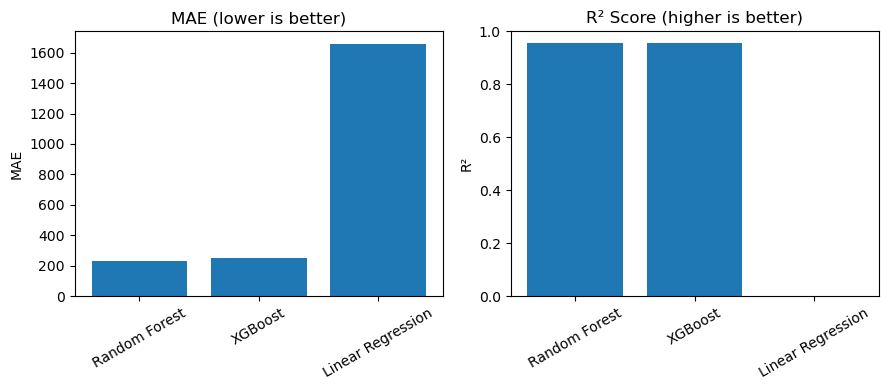

In [37]:
# -------------------------
# Model comparison: LR, XGBoost, RandomForest
# -------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Try to import XGBoost; if not installed print a helpful message
try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception as e:
    print("Warning: xgboost not available. Install with pip install xgboost to include XGBoost in comparison.")
    xgb_available = False

# ====== Models dictionary ======
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

if xgb_available:
    models["XGBoost"] = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)

# ====== Train / evaluate each model ======
results = []
for name, model in models.items():
    print(f"\nTraining & evaluating: {name} ...")
    model.fit(X_train, y_train)              # train
    y_pred = model.predict(X_test)           # predict
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    results.append({"Model": name, "MAE": mae, "R2": r2})
    # Optionally save each trained model (uncomment if you want)
    # import joblib
    # joblib.dump(model, f"models/{name.replace(' ', '_')}.pkl")

# ====== Results table ======
results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
print("\nModel comparison (sorted by MAE):")
display(results_df)

# Save results
results_df.to_csv("model_comparison.csv", index=False)
print("Saved comparison to model_comparison.csv")

# ====== Plot MAE and R2 ======
plt.figure(figsize=(9,4))
plt.subplot(1,2,1)
plt.bar(results_df['Model'], results_df['MAE'])
plt.title("MAE (lower is better)")
plt.ylabel("MAE")
plt.xticks(rotation=30)

plt.subplot(1,2,2)
plt.bar(results_df['Model'], results_df['R2'])
plt.title("R² Score (higher is better)")
plt.ylabel("R²")
plt.ylim(0,1)   # adjust if your R2 is outside [0,1]
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

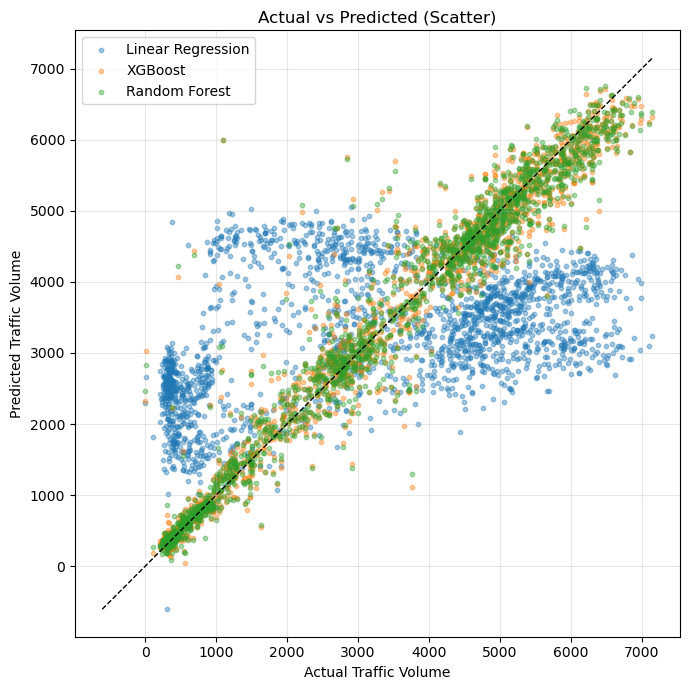

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# predictions (your variables)
lr_pred = lr_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
rf_pred = model.predict(X_test)
y_true = y_test.values if hasattr(y_test, "values") else np.array(y_test)

# sample for clarity
rng = np.random.default_rng(42)
idx = rng.choice(len(y_true), size=min(2000, len(y_true)), replace=False)

plt.figure(figsize=(7,7))
plt.scatter(y_true[idx], lr_pred[idx], s=10, alpha=0.4, label="Linear Regression")
plt.scatter(y_true[idx], xgb_pred[idx], s=10, alpha=0.4, label="XGBoost")
plt.scatter(y_true[idx], rf_pred[idx], s=10, alpha=0.4, label="Random Forest")

# y=x line
mn = min(y_true[idx].min(), lr_pred[idx].min(), xgb_pred[idx].min(), rf_pred[idx].min())
mx = max(y_true[idx].max(), lr_pred[idx].max(), xgb_pred[idx].max(), rf_pred[idx].max())
plt.plot([mn, mx], [mn, mx], color="k", linestyle="--", linewidth=1)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs Predicted (Scatter)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

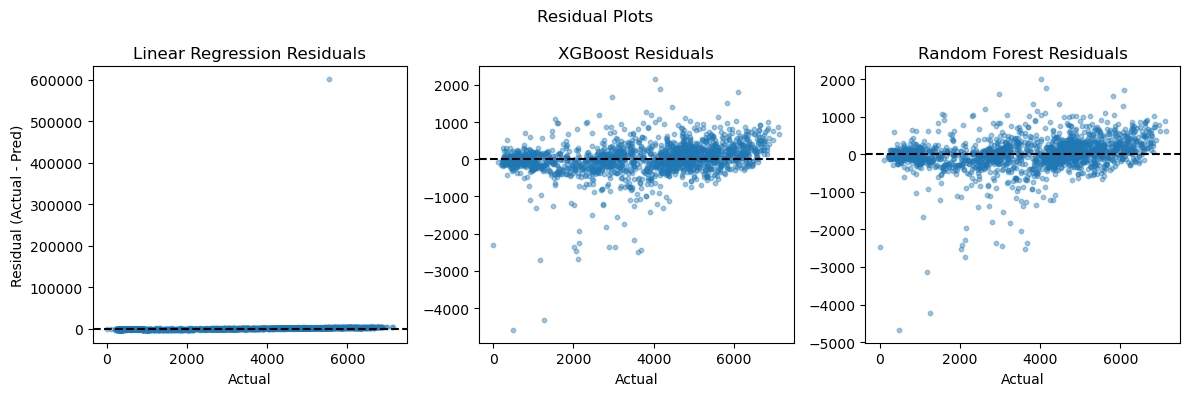

In [43]:
res_lr = y_true - lr_pred
res_xgb = y_true - xgb_pred
res_rf = y_true - rf_pred

idx = np.random.choice(len(y_true), size=min(2000, len(y_true)), replace=False)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.scatter(y_true[idx], res_lr[idx], s=10, alpha=0.4)
plt.axhline(0, color='k', linestyle='--')
plt.title("Linear Regression Residuals")
plt.xlabel("Actual"); plt.ylabel("Residual (Actual - Pred)")

plt.subplot(1,3,2)
plt.scatter(y_true[idx], res_xgb[idx], s=10, alpha=0.4)
plt.axhline(0, color='k', linestyle='--')
plt.title("XGBoost Residuals")
plt.xlabel("Actual")

plt.subplot(1,3,3)
plt.scatter(y_true[idx], res_rf[idx], s=10, alpha=0.4)
plt.axhline(0, color='k', linestyle='--')
plt.title("Random Forest Residuals")
plt.xlabel("Actual")

plt.suptitle("Residual Plots")
plt.tight_layout()
plt.show()

In [46]:
len(y_test), len(y_pred)

(9638, 9638)

In [47]:
low_th = df['traffic_volume'].quantile(0.33)
med_th = df['traffic_volume'].quantile(0.66)

def label_traffic(value):
    if value < low_th:
        return "Low"
    elif value < med_th:
        return "Medium"
    else:
        return "High"

In [48]:
traffic_levels = [label_traffic(p) for p in y_pred]
traffic_levels[:10]

['High',
 'Medium',
 'High',
 'High',
 'Medium',
 'Medium',
 'Low',
 'Medium',
 'Medium',
 'High']

In [49]:
import joblib
import json

# save trained model (RandomForest)
joblib.dump(model, "traffic_model.pkl")

# save thresholds for High/Medium/Low
low_th = df['traffic_volume'].quantile(0.33)
med_th = df['traffic_volume'].quantile(0.66)

thresholds = {
    "low": float(low_th),
    "medium": float(med_th)
}

with open("traffic_thresholds.json", "w") as f:
    json.dump(thresholds, f)

print("Saved: traffic_model.pkl and traffic_thresholds.json")

Saved: traffic_model.pkl and traffic_thresholds.json


In [50]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [51]:
import joblib

joblib.dump(model, r"C:\Users\prpa2\OneDrive\Desktop\traffic_dashboard\traffic_model.pkl")

print("Model saved successfully ✅")


Model saved successfully ✅


In [52]:
import json

low_th = df['traffic_volume'].quantile(0.33)
med_th = df['traffic_volume'].quantile(0.66)

thresholds = {
    "low": float(low_th),
    "medium": float(med_th)
}

with open(r"C:\Users\prpa2\OneDrive\Desktop\traffic_dashboard\traffic_thresholds.json", "w") as f:
    json.dump(thresholds, f)

print("Thresholds saved ✅")


Thresholds saved ✅
